In [ ]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pandas

kode diatas mengimpor beberapa library yang dibutuhkan. cv2 digunakan untuk membaca dan mengolah gambar, numpy dipakai karena gambar tersebut sebenarnya berupa array atau matriks angka, dan matplotlib digunakan untuk menampilkan gambar ke layar.

kode dibawah digunakan untuk membaca gambar menggunakan cv2.imread(). Angka 0 diakhir kode itu artinya gambar langsung diubah jadi grayscale atau abu-abu, jadi setiap piksel hanya mempunyai satu nilai dari 0 sampai 255. Nilai 0 itu hitam, dan 255 itu putih. Gambar yang dibaca disimpan ke dalam variabel dino1, dino2, dino3, dan dino4. Fungsi plt.subplot(2, 2, n) digunakan untuk membagi tampilan menjadi 2 baris dan 2 kolom, sehingga setiap gambar dapat ditampilkan secara berdampingan agar lebih mudah dibandingkan. Sementara itu, plt.axis('off') digunakan agar sumbu koordinat pada gambar tidak ditampilkan sehingga tampilan menjadi lebih rapi dan fokus pada citra saja.

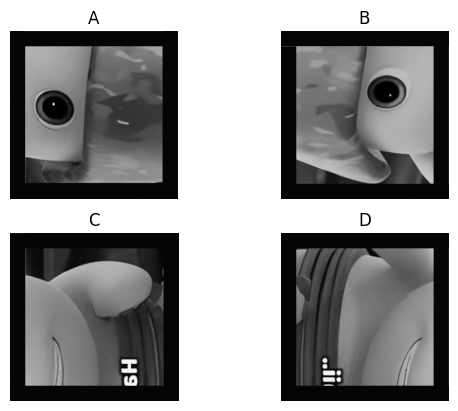

In [ ]:
dino1 = cv2.imread('assets/Dino-A.PNG', 0)
dino2 = cv2.imread('assets/Dino-B.PNG', 0)
dino3 = cv2.imread('assets/Dino-C.PNG', 0)
dino4 = cv2.imread('assets/Dino-D.PNG', 0) 

plt.subplot(2, 2, 1)
plt.title('A')
plt.imshow(dino1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(dino2, cmap='gray')
plt.title('B')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(dino3, cmap='gray')
plt.title('C')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(dino4, cmap='gray')
plt.title('D')
plt.axis('off')

plt.show()

kode dibawah ini digunakan untuk melakukan flip atau pencerminan gambar secara manual. Fungsi flip_image() menerima parameter gambar dan mode flip, yaitu 'x' untuk membalik gambar secara horizontal dan 'y' untuk membalik secara vertikal.
Program mengambil ukuran gambar menggunakan image.shape, lalu membuat array kosong untuk menyimpan hasil flip. Setelah itu, nested loop digunakan untuk memindahkan setiap piksel ke posisi baru sesuai mode yang dipilih. Pada mode 'x', gambar dibalik dari kanan ke kiri, sedangkan mode 'y' membalik gambar dari atas ke bawah.

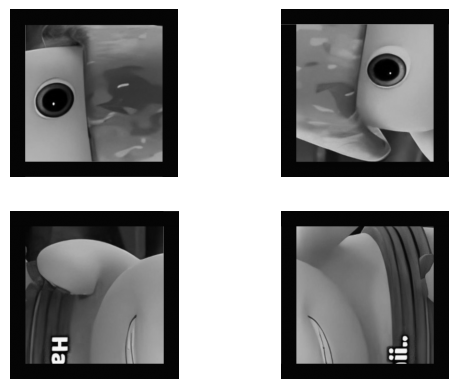

In [ ]:
def flip_image(image, mode='x'):
    h, w = image.shape
    result = np.zeros((h, w), dtype=image.dtype)
 
    for i in range(h):
        for j in range(w):
            if mode == 'x':
                result[i, j] = image[i, w-1-j]
            elif mode == 'y':
                result[i, j] = image[h-1-i, j]
    return result

plt.subplot (2, 2, 1)
flipdino1 = flip_image(dino1, 'y')
plt.imshow(flipdino1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(dino2, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
flipdino3 = flip_image(dino3, 'x')
plt.imshow(flipdino3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
flipdino4 = flip_image(dino4, 'x')
plt.imshow(flipdino4, cmap='gray')
plt.axis('off')

plt.show()

Kode di bawah ini digunakan untuk melakukan rotasi gambar dengan sudut tertentu menggunakan fungsi rotate_image(). Sudut rotasi dibatasi menggunakan angle % 360 agar tetap berada dalam rentang 0–359 derajat. Program kemudian memanfaatkan fungsi np.rot90() untuk memutar gambar sebesar 90°, 180°, atau 270° sesuai nilai k yang diberikan. Jika sudut tidak sesuai kondisi yang ada, maka gambar akan dikembalikan seperti semula. Setelah fungsi dibuat, beberapa gambar hasil flip sebelumnya diputar dengan sudut yang berbeda. dino1 dan dino3 diputar 90°, sedangkan dino2 dan dino4 diputar 270°. Pada dino2, hasil rotasi juga dibalik lagi menggunakan fungsi flip_image() agar sesuai dengan output yang diminta pada soal.


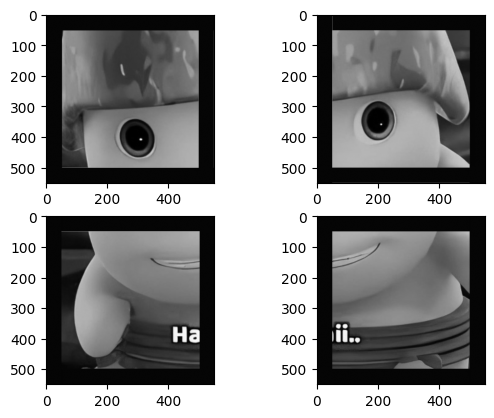

In [ ]:
def rotate_image(image, angle):
    angle = angle % 360
    h, w = image.shape

    if angle == 90:
        return np.rot90(image, k=1)
    elif angle == 180:
        return np.rot90(image, k=2)
    elif angle == 270:
        return np.rot90(image, k=3)
    else:
        return image

plt.subplot(2, 2, 1)
dino1_rot = rotate_image(flipdino1, 90)
plt.imshow(dino1_rot, cmap='gray')

plt.subplot(2, 2, 2)
dino2_rot = rotate_image(dino2, 270)
plt.imshow(dino2_rot, cmap='gray')
flipdino2 = flip_image(dino2_rot, 'x')
plt.imshow(flipdino2, cmap='gray')

plt.subplot(2, 2, 3)
dino3_rot = rotate_image(flipdino3, 90)  
plt.imshow(dino3_rot, cmap='gray')

plt.subplot(2, 2, 4)
dino4_rot = rotate_image(flipdino4, 270)
plt.imshow(dino4_rot, cmap='gray')

plt.show()

Kode di bawah ini digunakan untuk melakukan translasi atau pergeseran posisi gambar secara manual. Fungsi fungsi_lima() menerima parameter gambar, pergeseran kolom (geser_kolom_x), dan pergeseran baris (geser_baris_y). Program terlebih dahulu mengambil ukuran gambar lalu membuat array kosong dengan ukuran yang sama untuk menyimpan hasil translasi.
Selanjutnya, nested loop digunakan untuk membaca setiap piksel pada gambar asli. Posisi baru piksel dihitung menggunakan new_i dan new_j berdasarkan nilai pergeseran yang diberikan. Jika posisi baru masih berada dalam batas ukuran gambar, maka nilai piksel dipindahkan ke posisi tersebut pada array hasil. dino1 digeser ke kanan bawah, dino2 ke kiri bawah, dino3 ke kanan atas, dan dino4 ke kiri atas.

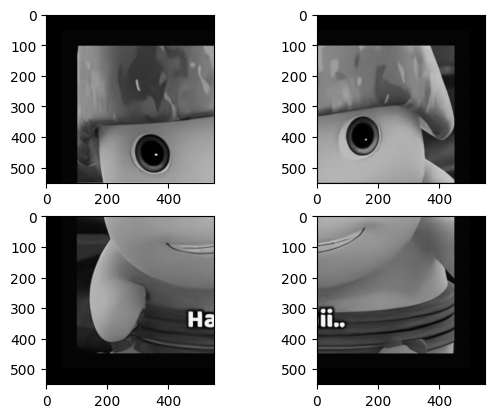

In [ ]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
                
    return hasil
plt.subplot(2, 2, 1)
dino1_trans = fungsi_lima(dino1_rot, 50, 50)
plt.imshow(dino1_trans, cmap='gray')

plt.subplot(2, 2, 2)
dino2_trans = fungsi_lima(flipdino2, -50, 50)
plt.imshow(dino2_trans, cmap='gray')

plt.subplot(2, 2, 3)
dino3_trans = fungsi_lima(dino3_rot, 50, -50)
plt.imshow(dino3_trans, cmap='gray')

plt.subplot(2, 2, 4)
dino4_trans = fungsi_lima(dino4_rot, -50, -50)
plt.imshow(dino4_trans, cmap='gray')
plt.show()


Kode di bawah ini digunakan untuk melakukan dilatasi atau memperbesar ukuran citra secara manual. Fungsi fungsi_tiga() membaca ukuran gambar lalu membuat array baru dengan ukuran dua kali lebih besar dari gambar asli. Proses pembesaran dilakukan menggunakan nested loop, di mana setiap piksel pada gambar asli disalin ke beberapa piksel pada array baru sehingga ukuran citra menjadi lebih besar.
Parameter p1, p2, p3, dan p4 digunakan untuk melakukan cropping pada hasil dilatasi agar bagian tertentu dari gambar dapat dipotong sesuai kebutuhan. Nilai sy, ey, sx, dan ex menentukan batas awal dan akhir area gambar yang akan diambil. Setiap gambar diperbesar dengan posisi potongan yang berbeda sehingga hasil akhirnya terlihat berada di arah yang berbeda-beda. 

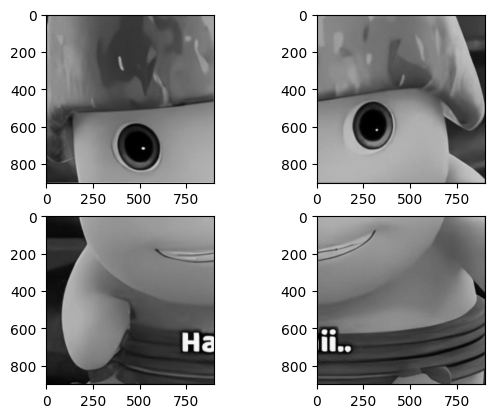

In [ ]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex] 


plt.subplot(2, 2, 1)
dino1_dil = fungsi_tiga(dino1_trans, 200, 0, 200, 0)
plt.imshow(dino1_dil, cmap='gray')

plt.subplot(2, 2, 2)
dino2_dil = fungsi_tiga(dino2_trans, 200, 0, 0, 200)
plt.imshow(dino2_dil, cmap='gray')

plt.subplot(2, 2, 3)
dino3_dil = fungsi_tiga(dino3_trans, 0, 200, 200, 0)
plt.imshow(dino3_dil, cmap='gray') 

plt.subplot(2, 2, 4)
dino4_dil = fungsi_tiga(dino4_trans, 0, 200, 0, 200)
plt.imshow(dino4_dil, cmap='gray')

plt.show()

Kode di bawah ini digunakan untuk menggabungkan beberapa citra menjadi satu gambar besar. Fungsi fungsi_dua_b() menggabungkan dua gambar secara horizontal atau menyamping dengan menghitung tinggi maksimum dan menjumlahkan lebarnya. Setelah itu dibuat array kosong sebagai tempat hasil gabungan, lalu kedua gambar dimasukkan ke posisi kanan dan kiri. Sedangkan fungsi fungsi_dua_c() digunakan untuk menggabungkan gambar secara vertikal atau atas-bawah. Tinggi gambar dijumlahkan, sedangkan lebarnya diambil yang paling besar. Kedua gambar kemudian ditempatkan pada array hasil sesuai posisinya. Lalu kedua hasil tersebut digabung kembali menjadi satu citra besar bernama hasil_gabungan.


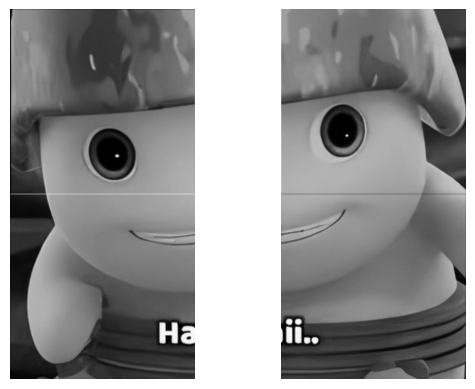

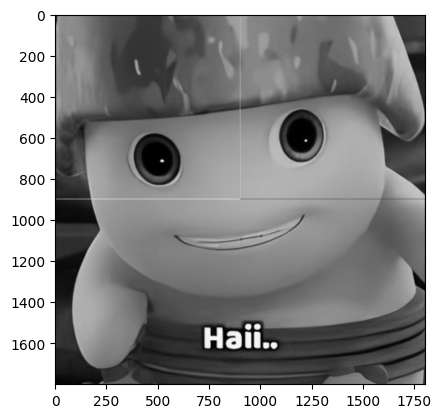

In [ ]:
def fungsi_dua_b(dino1_dil, dino3_dil): 
    c1, c2 = np.array(dino1_dil), np.array(dino3_dil) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def fungsi_dua_c(dino2_dil, dino4_dil): 
    c1, c2 = np.array(dino2_dil), np.array(dino4_dil) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 

plt.subplot(1, 2, 1)
hasil_c = fungsi_dua_c(dino1_dil, dino3_dil)
plt.imshow(hasil_c, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2) 
hasil_b = fungsi_dua_c(dino2_dil, dino4_dil)
plt.imshow(hasil_b, cmap='gray')
plt.axis('off')

plt.show()
hasil_gabungan = fungsi_dua_b(hasil_c, hasil_b)
plt.imshow(hasil_gabungan, cmap='gray')
plt.show()

kode dibawah digunakan untuk membaca gambar menggunakan cv2.imread(). Angka 0 diakhir kode itu artinya gambar langsung diubah jadi grayscale atau abu-abu, jadi setiap piksel hanya mempunyai satu nilai dari 0 sampai 255. Nilai 0 itu hitam, dan 255 itu putih. Gambar yang dibaca disimpan ke dalam variabel kacamata, money dan udud.

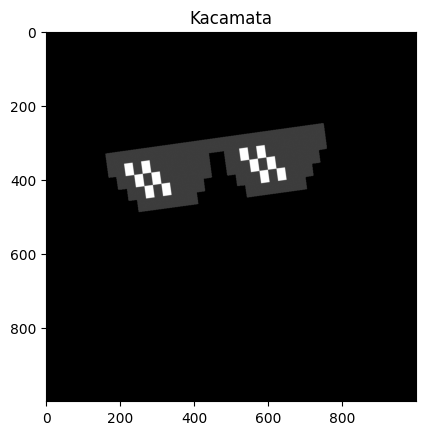

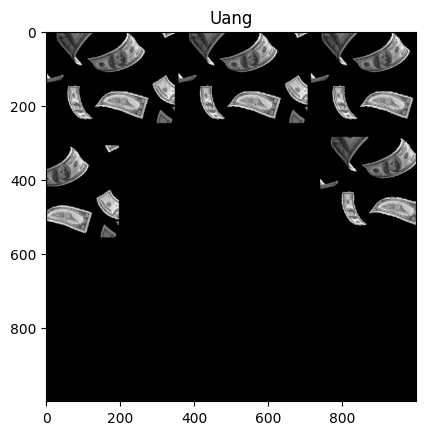

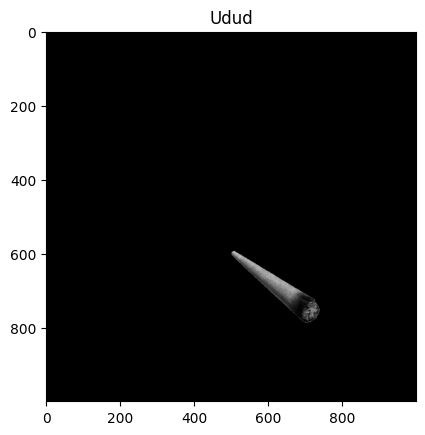

In [ ]:
kacamata = cv2.imread('assets/Kacamata.PNG', 0)
money = cv2.imread('assets/money.PNG', 0)
udud = cv2.imread('assets/udud.PNG', 0)

plt.title('Kacamata')
plt.imshow(kacamata, cmap='gray')
plt.show()

plt.imshow(money, cmap='gray')
plt.title('Uang')
plt.show()

plt.imshow(udud, cmap='gray')
plt.title('Udud')
plt.show()

Kode di bawah ini digunakan untuk mengubah ukuran gambar atribut seperti kacamata, uang, dan udud menjadi ukuran yang sama yaitu 1800×1800 piksel menggunakan fungsi cv2.resize(). Proses resize dilakukan agar semua gambar memiliki dimensi yang sesuai saat digabungkan dengan citra utama sehingga tidak terjadi error ukuran berbeda jika saat dilakukan penjumlahan.

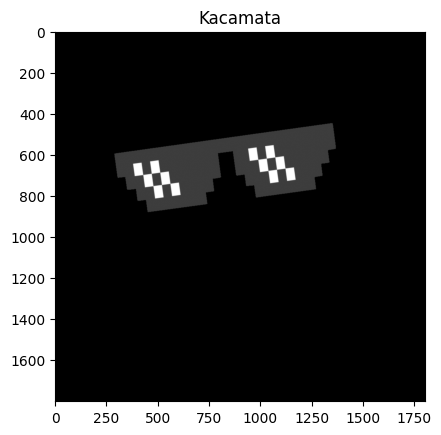

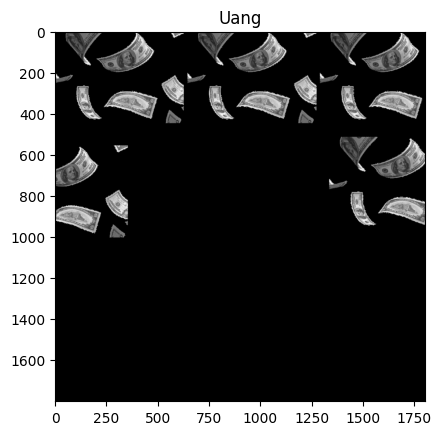

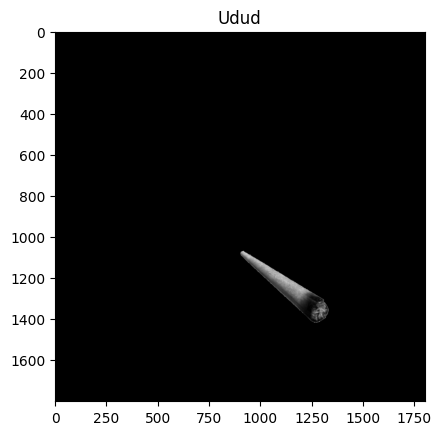

In [ ]:
kacamata = cv2.resize(kacamata, (1800, 1800))
money = cv2.resize(money, (1800, 1800))
udud = cv2.resize(udud, (1800, 1800))

plt.title('Kacamata')
plt.imshow(kacamata, cmap='gray')
plt.show()

plt.imshow(money, cmap='gray')
plt.title('Uang')
plt.show()

plt.imshow(udud, cmap='gray')
plt.title('Udud')
plt.show()

Kode tersebut digunakan untuk menggabungkan objek tambahan ke gambar utama tanpa membuat objek terlihat transparan atau gelap. Fungsi merge() membuat salinan dari gambar background, lalu membuat mask dengan kondisi objek > 10. Artinya hanya piksel objek yang memiliki nilai lebih dari 10 yang akan diambil, sedangkan bagian hitam pada background objek diabaikan. Baris hasil[mask] = objek[mask] mengganti piksel pada background dengan piksel objek sesuai area mask sehingga objek seperti kacamata, uang, dan udud dapat menempel dengan jelas pada gambar utama. Setelah itu proses merge dilakukan bertahap hingga semua objek tergabung ke dalam satu citra.


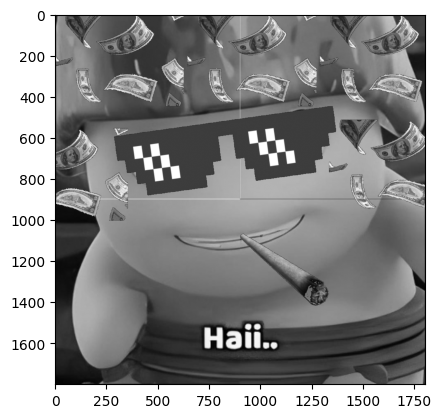

In [ ]:
def merge(background, objek):
    hasil = background.copy()

    mask = objek > 10

    hasil[mask] = objek[mask]

    return hasil
hasil = merge(hasil_gabungan, kacamata)
hasil = merge(hasil, money)
hasil = merge(hasil, udud)

plt.imshow(hasil, cmap='gray')
plt.show()

Kode tersebut digunakan untuk menampilkan perbandingan histogram antara citra sebelum dan sesudah penambahan atribut kacamata, money dan udud. Histogram pertama berasal dari hasil_gabungan, sedangkan histogram kedua berasal dari citra akhir hasil. Fungsi ravel() dipakai untuk mengubah seluruh piksel gambar menjadi satu baris data agar mudah dihitung distribusi intensitasnya.
Parameter bins=256 menunjukkan bahwa histogram memiliki 256 tingkat intensitas grayscale dari 0–255. Warna biru digunakan untuk histogram gambar awal dan warna oranye untuk histogram gambar hasil gabungan. Nilai alpha=0.7 membuat kedua histogram terlihat transparan sehingga perbedaannya dapat dibandingkan dengan lebih jelas.
Dari hasil histogram dapat terlihat bahwa setelah atribut ditambahkan, distribusi nilai piksel mengalami perubahan pada beberapa intensitas. Hal ini menunjukkan bahwa proses penggabungan objek memengaruhi pencahayaan dan komposisi piksel pada citra akhir.

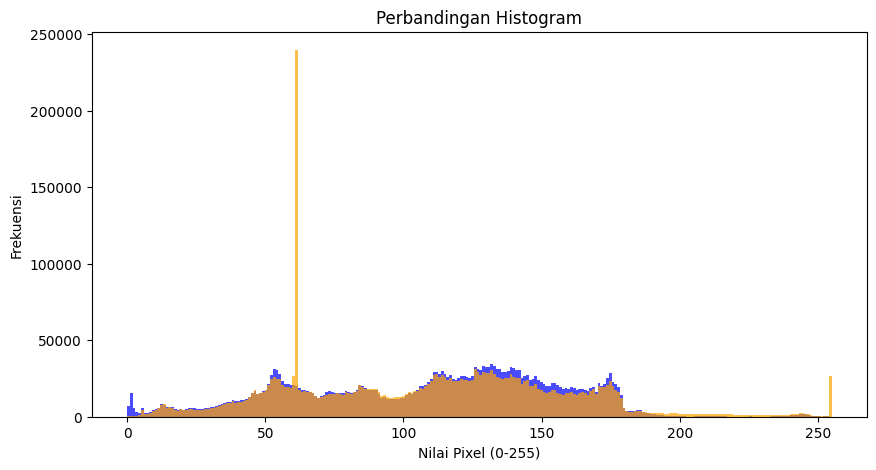

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(hasil_gabungan.ravel(),
         bins=256,
         range=(0,255),
         color='blue',
         alpha=0.7,
         label='New Image')

plt.hist(hasil.ravel(),
         bins=256,
         range=(0,255),
         color='orange',
         alpha=0.7,
         label='Gabungan')

plt.title("Perbandingan Histogram")
plt.xlabel("Nilai Pixel (0-255)")
plt.ylabel("Frekuensi")

plt.show()